In [26]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from poclib import config, gbq, schema_discovery, congress, analysis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
# matplotlib parameters
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 16,
    "figure.titlesize": 18,
})

In [3]:
congressperson_amplified_pubs = pd.read_parquet(config.OUTPUT_DIR / "amplified_attributes.parquet")
congressperson_amplified_mentions = pd.read_parquet(config.OUTPUT_DIR / "congress_amplified_mentions.parquet")
grants_for_amplified_pubs = pd.read_parquet(config.OUTPUT_DIR / "amplified_grants.parquet")
congressperson_amplified_mentions["year"] = congressperson_amplified_mentions["mention_date"].dt.year

In [5]:
congressperson_amplified_pubs.head()

,pub_id,doi,title,year,source_title,times_cited,field_citation_ratio,altmetric_score,n_authors,n_funders,n_research_orgs,for_code,for_name,funder_grids,research_grids,author_last_names,funder_names,funder_types,research_org_names
0,pub.1004751246,10.1038/scientificamerican1014-42,How Diversity Works,2022,Scientific American,210,319.23,9696,1,0,0,36,Creative Arts and Writing,[],[],[Phillips],[],[],[]
1,pub.1004751246,10.1038/scientificamerican1014-42,How Diversity Works,2022,Scientific American,210,319.23,9696,1,0,0,47,"Language, Communication and Culture",[],[],[Phillips],[],[],[]
2,pub.1056566186,10.1038/scientificamerican0722-42,Climate Miseducation,2022,Scientific American,1,NaN,879,1,0,0,NaN,NaN,[],[],[Worth],[],[],[]
3,pub.1138614686,10.1101/2021.06.01.21258176,Necessity of COVID-19 Vaccination in Persons w...,2021,medRxiv,30,9.21,9131,5,0,1,32,Biomedical and Clinical Sciences,[],[grid.239578.2],"[Shrestha, Burke, Nowacki, Terpeluk, Gordon]",[],[],[Cleveland Clinic]
4,pub.1139078733,10.1101/2021.06.18.449051,Recovery of deleted deep sequencing data sheds...,2021,bioRxiv,6,0.97,4386,1,2,1,31,Biological Sciences,"[grid.413575.1, grid.453125.4]",[grid.270240.3],[Bloom],"[Howard Hughes Medical Institute, Office of th...","[Government, Nonprofit]",[Fred Hutchinson Cancer Center]


In [7]:
congressperson_amplified_mentions.head()

,pub_id,screen_name,channel,followers,mention_date,party,member
0,pub.1124242046,sentomcotton,tw,687744,2020-01-30 02:12:14+00:00,Republican,Tom Cotton
1,pub.1067984501,repbeatty,tw,75149,2016-11-18 20:24:01+00:00,Democrat,Joyce Beatty
2,pub.1140641988,repthomasmassie,tw,915809,2021-09-16 17:03:15+00:00,Republican,Thomas Massie
3,pub.1131389330,johncornyn,tw,413393,2020-10-01 19:12:02+00:00,Republican,John Cornyn
4,pub.1139238884,berniemoreno,tw,32915,2021-09-06 00:27:30+00:00,Republican,Bernie Moreno


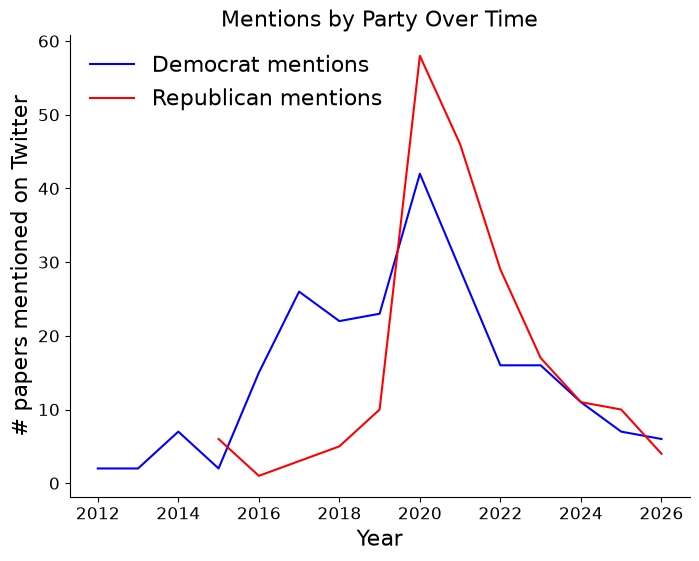

In [35]:
partisan_mentions_by_year = congressperson_amplified_mentions.groupby(['year', 'party']).agg(
    mentions=('pub_id', 'nunique')
).reset_index()
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(partisan_mentions_by_year[partisan_mentions_by_year['party'] == 'Democrat']['year'],
        partisan_mentions_by_year[partisan_mentions_by_year['party'] == 'Democrat']['mentions'], label='Democrat mentions', color='blue')
ax.plot(partisan_mentions_by_year[partisan_mentions_by_year['party'] == 'Republican']['year'],
        partisan_mentions_by_year[partisan_mentions_by_year['party'] == 'Republican']['mentions'], label='Republican mentions', color='red')
ax.set_xlabel('Year')
ax.set_ylabel('# papers mentioned on Twitter')
ax.set_title('Mentions by Party Over Time')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

In [5]:
# number of mentions and followers by person and by party
mentions_by_person = congressperson_amplified_mentions.groupby('member').agg(
    mentions=('pub_id', 'nunique'),
    followers=('followers', 'first'),
    party=('party', 'first')
).reset_index()
mentions_by_person.head()

,member,mentions,followers,party
0,Adam Smith,1,46196,Democrat
1,Alma S. Adams,3,30372,Democrat
2,Amy Klobuchar,1,96297,Democrat
3,Andy Biggs,26,1098093,Republican
4,Andy Harris,7,31015,Republican


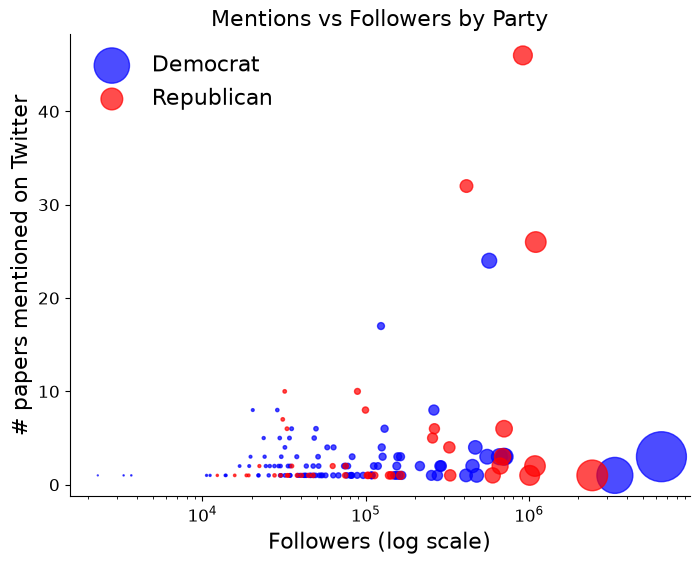

In [37]:
# visualize by party
fig, ax = plt.subplots(figsize=(8, 6))
for party, group in mentions_by_person.groupby('party'):
    ax.scatter(group['followers'], group['mentions'], label=party, alpha=0.7, c=group['party'].map({'Democrat': 'blue', 'Republican': 'red'}), s=group['followers'] / 5000)  # size by followers
ax.set_xscale('log')
ax.set_xlabel('Followers (log scale)')
ax.set_ylabel('# papers mentioned on Twitter')
ax.set_title('Mentions vs Followers by Party')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.savefig(config.OUTPUT_DIR / "mentions_vs_followers_by_party.png", dpi=300, bbox_inches="tight")

In [7]:
# who is funding the research that is amplified by congresspeople of each party?
mentions_by_party_with_funding = congressperson_amplified_pubs.merge(
    congressperson_amplified_mentions[["pub_id", "party"]].drop_duplicates(),
    on="pub_id",
    how="left",
)
mentions_by_party_with_funding = mentions_by_party_with_funding.merge(
    grants_for_amplified_pubs[["pub_id", "grant_id", "funding_usd"]].drop_duplicates(),
    on="pub_id",
    how="left",
)
mentions_by_party_with_funding.head()

,pub_id,doi,title,year,source_title,times_cited,field_citation_ratio,altmetric_score,n_authors,n_funders,...,for_name,funder_grids,research_grids,author_last_names,funder_names,funder_types,research_org_names,party,grant_id,funding_usd
0,pub.1004751246,10.1038/scientificamerican1014-42,How Diversity Works,2022,Scientific American,210,319.23,9696,1,0,...,Creative Arts and Writing,[],[],[Phillips],[],[],[],Democrat,NaN,NaN
1,pub.1004751246,10.1038/scientificamerican1014-42,How Diversity Works,2022,Scientific American,210,319.23,9696,1,0,...,"Language, Communication and Culture",[],[],[Phillips],[],[],[],Democrat,NaN,NaN
2,pub.1056566186,10.1038/scientificamerican0722-42,Climate Miseducation,2022,Scientific American,1,NaN,879,1,0,...,NaN,[],[],[Worth],[],[],[],Democrat,NaN,NaN
3,pub.1138614686,10.1101/2021.06.01.21258176,Necessity of COVID-19 Vaccination in Persons w...,2021,medRxiv,30,9.21,9131,5,0,...,Biomedical and Clinical Sciences,[],[grid.239578.2],"[Shrestha, Burke, Nowacki, Terpeluk, Gordon]",[],[],[Cleveland Clinic],Republican,NaN,NaN
4,pub.1139078733,10.1101/2021.06.18.449051,Recovery of deleted deep sequencing data sheds...,2021,bioRxiv,6,0.97,4386,1,2,...,Biological Sciences,"[grid.413575.1, grid.453125.4]",[grid.270240.3],[Bloom],"[Howard Hughes Medical Institute, Office of th...","[Government, Nonprofit]",[Fred Hutchinson Cancer Center],Republican,grant.9018323,2000000.0


In [8]:
papers_with_funding_type_by_party = mentions_by_party_with_funding.explode('funder_types').groupby(['party', 'funder_types'])["pub_id"].nunique().reset_index().pivot(index='funder_types', columns='party', values='pub_id').fillna(0).sort_values(by=['Democrat', 'Republican'], ascending=False)
total_papers_with_funding_by_party = mentions_by_party_with_funding[
    mentions_by_party_with_funding
['funder_types'].apply(lambda x: len(x) > 0)
].groupby('party')['pub_id'].nunique().reset_index().rename(columns={'pub_id': 'total_papers_with_funding'})
total_papers_with_funding_by_party

,party,total_papers_with_funding
0,Democrat,67
1,Republican,89


In [9]:
papers_with_funder_by_party = (
    mentions_by_party_with_funding.explode("funder_names")
    .groupby(["party", "funder_names"])["pub_id"]
    .nunique()
    .reset_index()
    .pivot(index="funder_names", columns="party", values="pub_id")
    .fillna(0)
    .sort_values(by=["Democrat", "Republican"], ascending=False)
)

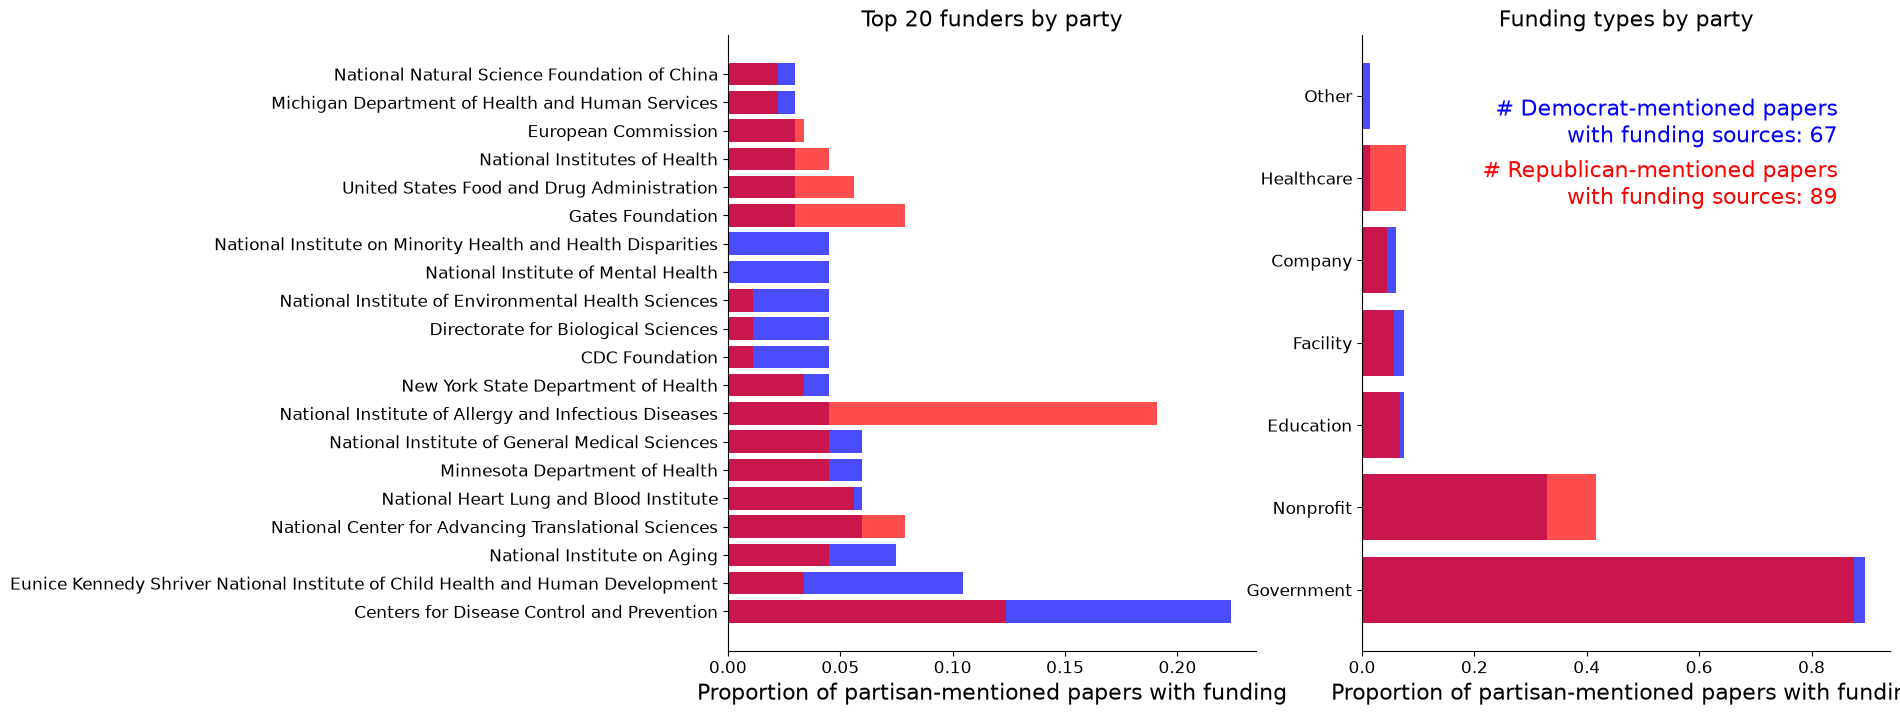

In [38]:
n_democrat_papers_with_funding_sources = total_papers_with_funding_by_party[
    total_papers_with_funding_by_party
.party == "Democrat"
]["total_papers_with_funding"].values[0]
n_republican_papers_with_funding_sources = total_papers_with_funding_by_party[
    total_papers_with_funding_by_party
.party == "Republican"]["total_papers_with_funding"].values[0]
democrat_funders = (
    papers_with_funder_by_party["Democrat"].head(20)
    / n_democrat_papers_with_funding_sources
)
republican_funders = (
    papers_with_funder_by_party["Republican"].head(20) / n_republican_papers_with_funding_sources
)
fig, (ax_funders, ax_types) = plt.subplots(1, 2, figsize=(15, 8))
ax_funders.barh(
    democrat_funders.index,
    democrat_funders.values,
    color="blue",
    alpha=0.7,
    label="Democrat",
)
ax_funders.barh(
    republican_funders.index,
    republican_funders.values,
    color="red",
    alpha=0.7,
    label="Republican",
)
ax_funders.set_xlabel("Proportion of partisan-mentioned papers with funding")
ax_funders.set_title("Top 20 funders by party")
ax_funders.spines[['top', 'right']].set_visible(False)

ax_types.barh(
    papers_with_funding_type_by_party.index,
    papers_with_funding_type_by_party["Democrat"] / n_democrat_papers_with_funding_sources,
    color="blue",
    alpha=0.7,
    label="Democrat",
)
ax_types.barh(
    papers_with_funding_type_by_party.index,
    papers_with_funding_type_by_party["Republican"] / n_republican_papers_with_funding_sources,
    color="red",
    alpha=0.7,
    label="Republican",
)
# text annotations with denominator in top right
ax_types.text(
    0.9,
    0.9,
    f"# Democrat-mentioned papers\nwith funding sources: {n_democrat_papers_with_funding_sources}",
    transform=ax_types.transAxes,
    ha="right",
    va="top",
    fontsize=16,
    color="blue"
)
ax_types.text(
    0.9,
    0.8,
    f"# Republican-mentioned papers\nwith funding sources: {n_republican_papers_with_funding_sources}",
    transform=ax_types.transAxes,
    ha="right",
    va="top",
    fontsize=16,
    color="red"
)
ax_types.set_xlabel("Proportion of partisan-mentioned papers with funding")
ax_types.set_title("Funding types by party")
ax_types.spines[['top', 'right']].set_visible(False)
fig.savefig(config.OUTPUT_DIR / "funding_types_and_funders_by_party.png", dpi=300, bbox_inches="tight")

In [12]:
papers_with_funding_type_by_party.head()

party,Democrat,Republican
funder_types,,
Government,60.0,78.0
Nonprofit,22.0,37.0
Education,5.0,6.0
Facility,5.0,5.0
Company,4.0,4.0


In [13]:
# chi-square test for independence between party and funding type
from scipy.stats import chi2_contingency
contingency_table = papers_with_funding_type_by_party.fillna(0).values
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic for funding types: {chi2:.4f}, p-value: {p:.4e}, degrees of freedom: {dof}")
funders_contingency_table = papers_with_funder_by_party.fillna(0).values
chi2_funders, p_funders, dof_funders, expected_funders = chi2_contingency(funders_contingency_table)
print(f"Chi-square statistic for funders: {chi2_funders:.4f}, p-value: {p_funders:.4e}, degrees of freedom: {dof_funders}")

Chi-square statistic for funding types: 5.4295, p-value: 4.9002e-01, degrees of freedom: 6
Chi-square statistic for funders: 254.7538, p-value: 1.3564e-01, degrees of freedom: 231


Text(0.5, 1.0, 'Distribution of grant sizes for Democrat- and Republican-mentioned papers')

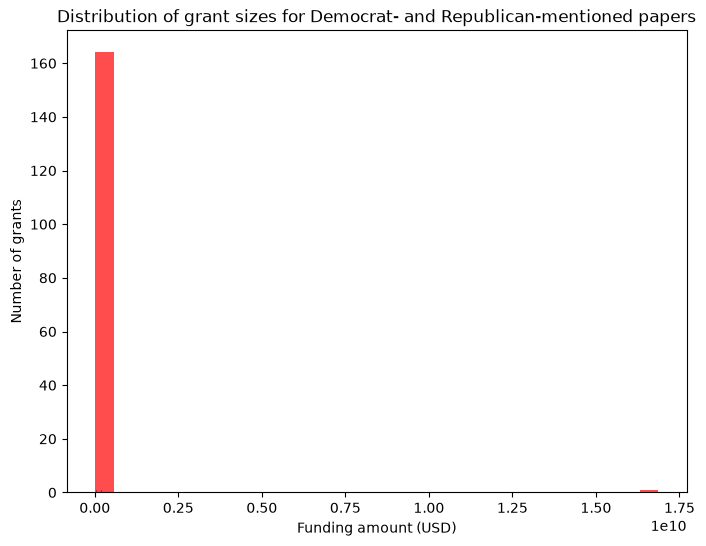

In [97]:
# distribution of grant sizes for democrat- and republican-mentioned papers
funding_amounts_by_party = mentions_by_party_with_funding.drop_duplicates(subset=["party", "grant_id"])[["party", "funding_usd"]].dropna()
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(
    funding_amounts_by_party[funding_amounts_by_party["party"] == "Democrat"]["funding_usd"],
    bins=30,
    alpha=0.7,
    label="Democrat",
    color="blue",
)
ax.hist(
    funding_amounts_by_party[funding_amounts_by_party["party"] == "Republican"]["funding_usd"],
    bins=30,
    alpha=0.7,
    label="Republican",
    color="red",
)
ax.set_xlabel("Funding amount (USD)")
ax.set_ylabel("Number of grants")
ax.set_title("Distribution of grant sizes for Democrat- and Republican-mentioned papers")

In [15]:
institutions = pd.read_parquet(config.OUTPUT_DIR / "amplified_institutions.parquet")
prestige = pd.read_csv(config.INPUT_DIR / "ror_to_institution_prestige.csv")
inst_prestige = analysis.attach_prestige(
    institutions, prestige
)

In [18]:
mentions_by_party_with_institution = congressperson_amplified_pubs.merge(
    congressperson_amplified_mentions[["pub_id", "party"]].drop_duplicates(),
    on="pub_id",
    how="left",
).merge(inst_prestige, on="pub_id", how="left")
mentions_by_party_with_institution = mentions_by_party_with_institution[["pub_id", "party", "normalized_ordinal_prestige"]].dropna(subset=["normalized_ordinal_prestige"]).drop_duplicates()
mentions_by_party_with_institution.head()

,pub_id,party,normalized_ordinal_prestige
17,pub.1129884176,Republican,0.983759
18,pub.1129975416,Republican,0.988399
23,pub.1152262917,Republican,0.867749
24,pub.1152262917,Republican,0.969838
34,pub.1148690036,Republican,0.974478


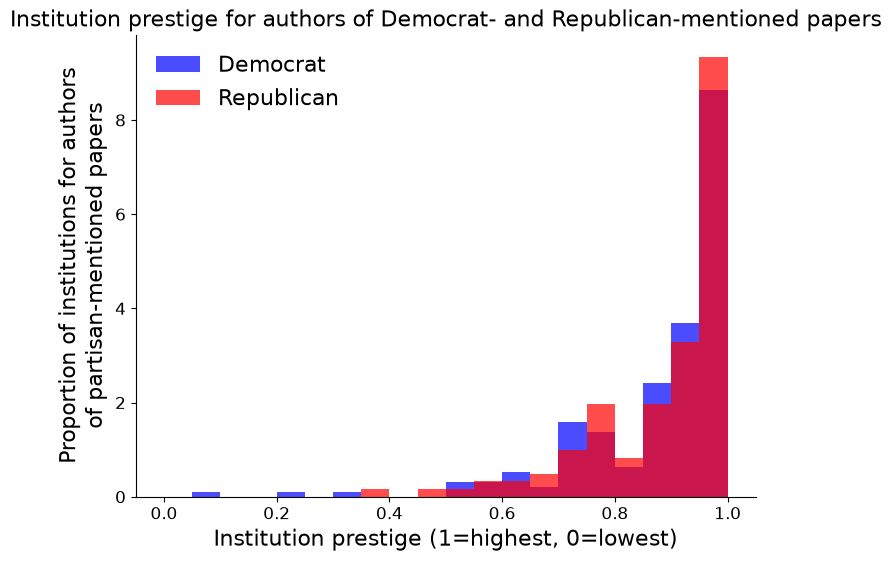

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
prestige_bins = np.linspace(0, 1, 21)
ax.hist(
    mentions_by_party_with_institution[
        mentions_by_party_with_institution["party"] == "Democrat"
    ]["normalized_ordinal_prestige"],
    bins=prestige_bins,
    alpha=0.7,
    label="Democrat",
    color="blue",
    density=True
)
ax.hist(
    mentions_by_party_with_institution[
        mentions_by_party_with_institution["party"] == "Republican"
    ]["normalized_ordinal_prestige"],
    bins=prestige_bins,
    alpha=0.7,
    label="Republican",
    color="red",
    density=True
)
ax.set_xlabel("Institution prestige (1=highest, 0=lowest)")
ax.set_ylabel("Proportion of institutions for authors\nof partisan-mentioned papers")
ax.set_title("Institution prestige for authors of Democrat- and Republican-mentioned papers")
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.savefig(config.OUTPUT_DIR / "institution_prestige_by_party.png", dpi=300, bbox_inches="tight")

In [33]:
# mann-whitney U test for difference in institution prestige between parties
from scipy.stats import mannwhitneyu
democrat_prestige = mentions_by_party_with_institution[
    mentions_by_party_with_institution["party"] == "Democrat"]["normalized_ordinal_prestige"]
republican_prestige = mentions_by_party_with_institution[
    mentions_by_party_with_institution["party"] == "Republican"]["normalized_ordinal_prestige"]
u_statistic, p_value = mannwhitneyu(democrat_prestige, republican_prestige, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_statistic}, p-value: {p_value:.4e}")

Mann-Whitney U statistic: 11126.0, p-value: 5.5090e-01
